<a href="https://colab.research.google.com/github/atulyavm/phishing_detection/blob/main/Phishing_Website_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing the libraries

In [1]:
!pip install liac-arff

  Preparing metadata (setup.py) ... done
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=d7869595822566aaf56f5dca3b1d88b883db4476d1f7c8945fb522bb3cf5d7a5
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff


Importing the libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arff

Loading the dataset

In [3]:
data = arff.load(open('Training Dataset.arff'))

df = pd.DataFrame(data['data'])

df.head()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


Add Columns Name

In [4]:
columns = [
    'having_IP_Address',
    'URL_Length',
    'Shortining_Service',
    'having_At_Symbol',
    'double_slash_redirecting',
    'Prefix_Suffix',
    'having_Sub_Domain',
    'SSLfinal_State',
    'Domain_registeration_length',
    'Favicon',
    'port',
    'HTTPS_token',
    'Request_URL',
    'URL_of_Anchor',
    'Links_in_tags',
    'SFH',
    'Submitting_to_email',
    'Abnormal_URL',
    'Redirect',
    'on_mouseover',
    'RightClick',
    'popUpWidnow',
    'Iframe',
    'age_of_domain',
    'DNSRecord',
    'web_traffic',
    'Page_Rank',
    'Google_Index',
    'Links_pointing_to_page',
    'Statistical_report',
    'Result'
]

df.columns = columns

Basic Dataset Inspection

In [5]:
df.head()

df.shape

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   having_IP_Address            11055 non-null  object
 1   URL_Length                   11055 non-null  object
 2   Shortining_Service           11055 non-null  object
 3   having_At_Symbol             11055 non-null  object
 4   double_slash_redirecting     11055 non-null  object
 5   Prefix_Suffix                11055 non-null  object
 6   having_Sub_Domain            11055 non-null  object
 7   SSLfinal_State               11055 non-null  object
 8   Domain_registeration_length  11055 non-null  object
 9   Favicon                      11055 non-null  object
 10  port                         11055 non-null  object
 11  HTTPS_token                  11055 non-null  object
 12  Request_URL                  11055 non-null  object
 13  URL_of_Anchor                11

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
count,11055,11055,11055,11055,11055,11055,11055,11055,11055,11055,...,11055,11055,11055,11055,11055,11055,11055,11055,11055,11055
unique,2,3,2,2,2,2,3,3,2,2,...,2,2,2,2,3,2,2,3,2,2
top,1,-1,1,1,1,-1,1,1,-1,1,...,1,1,1,1,1,-1,1,0,1,1
freq,7262,8960,9611,9400,9626,9590,4070,6331,7389,9002,...,8918,10043,5866,7612,5831,8201,9516,6156,9505,6157


Check Missing Values

In [6]:
df.isnull().sum()

,0
having_IP_Address,0
URL_Length,0
Shortining_Service,0
having_At_Symbol,0
double_slash_redirecting,0
Prefix_Suffix,0
having_Sub_Domain,0
SSLfinal_State,0
Domain_registeration_length,0
Favicon,0


Check Duplicates

In [7]:
df.duplicated().sum()

np.int64(5206)

Remove Duplicates

In [8]:
df.drop_duplicates(inplace=True)

Convert Target Labels

In [9]:
df['Result'] = df['Result'].replace({
    -1: 0,
     1: 1
})

Class Distribution Visualization

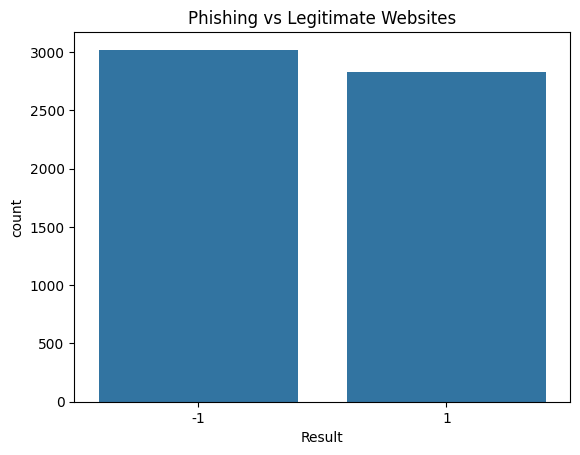

In [14]:
sns.countplot(x='Result', data=df)

plt.title("Phishing vs Legitimate Websites")

plt.show()

Correlation Heatmap

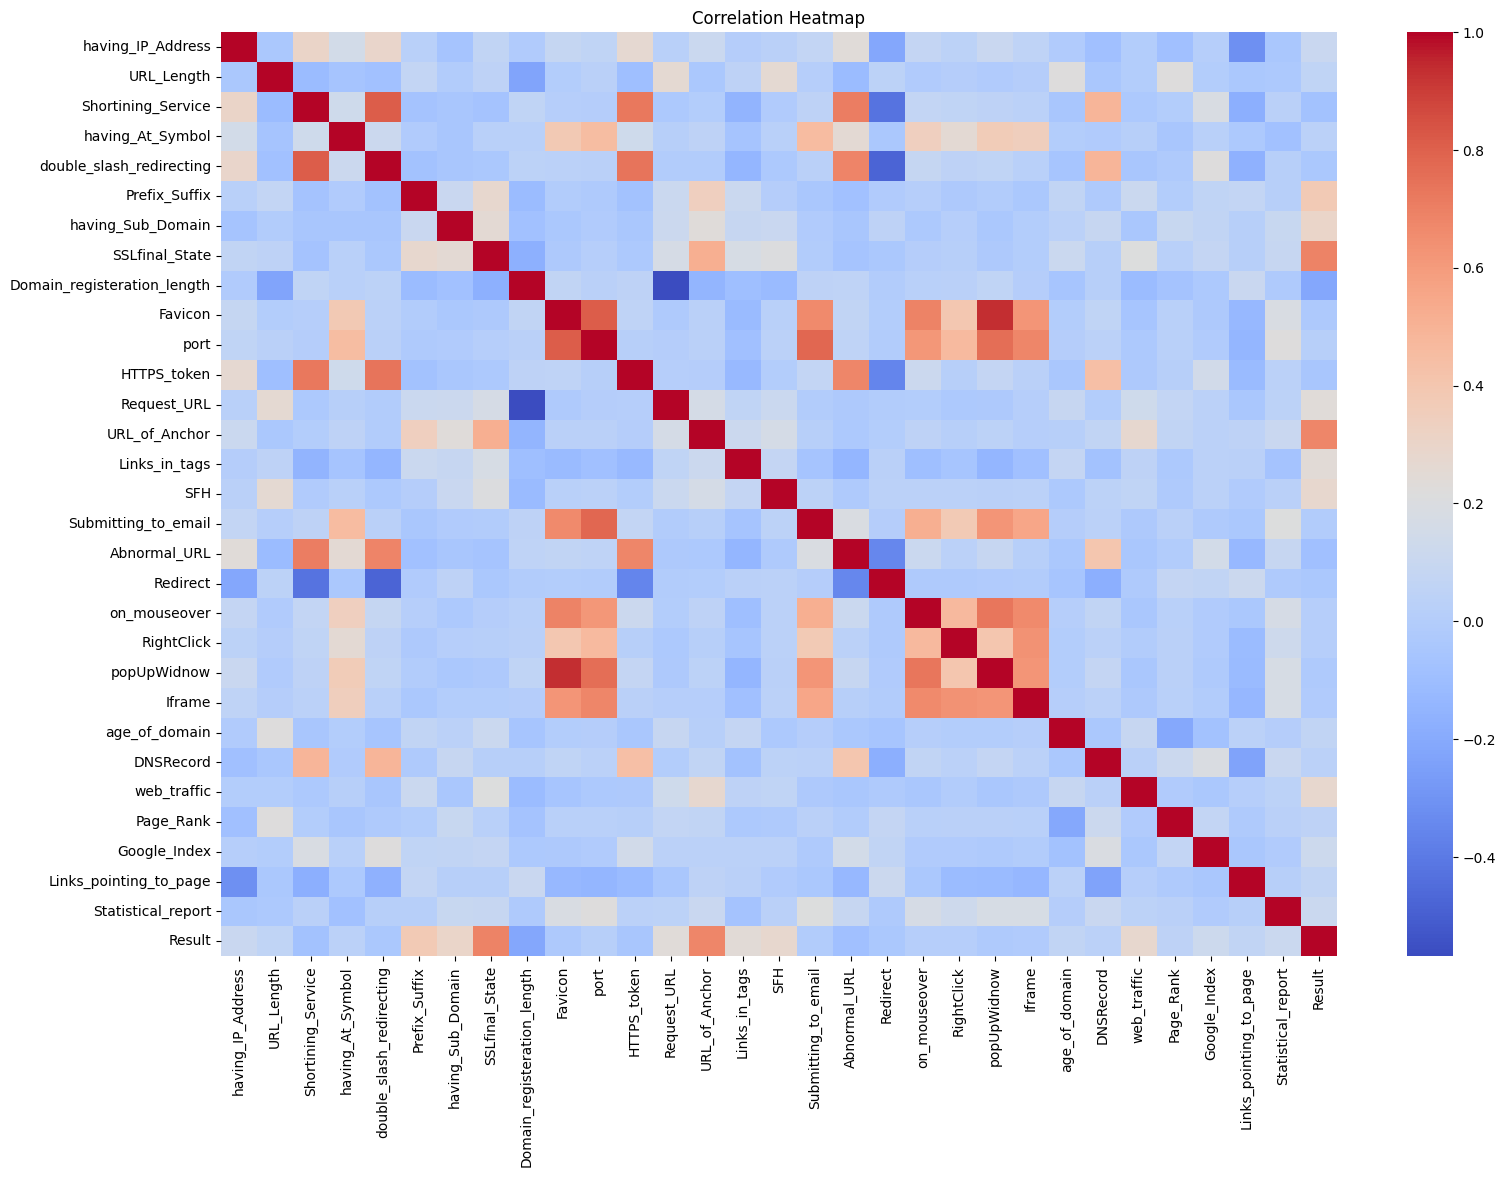

In [10]:
plt.figure(figsize=(18,12))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

Separate Features & Target

In [11]:
X = df.drop('Result', axis=1)

y = df['Result']

Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Feature Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)